In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("ecommerce_data.csv")
df["Order_Time"] = pd.to_datetime(df["Order_Time"])

In [9]:
print(df.head())

  Order_ID     Product  Quantity Order_Time User_ID  Rating
0   O00001      Spices         3 2023-01-12   U0001       2
1   O00002      Spices         1 2023-01-01   U0002       2
2   O00003    Biscuits         2 2023-01-23   U0003       4
3   O00004  Cold Drink         1 2023-01-05   U0004       1
4   O00005      Spices         1 2023-01-08   U0005       1


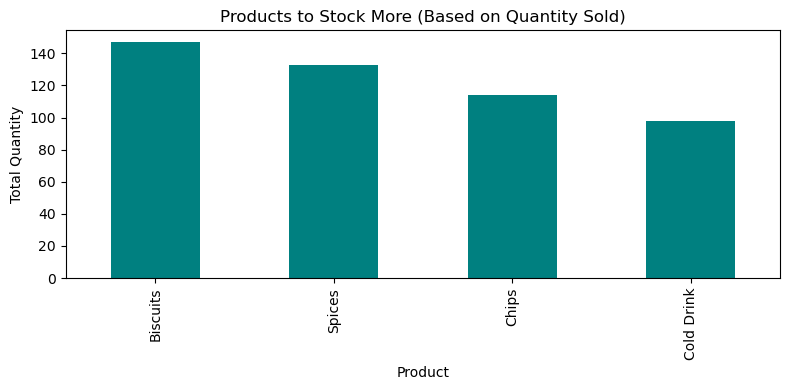

In [10]:
stock_data = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
stock_data.plot(kind="bar", color="teal")
plt.title("Products to Stock More (Based on Quantity Sold)")
plt.ylabel("Total Quantity")
plt.xlabel("Product")
plt.tight_layout()
plt.show()

In [12]:
user_orders = df["User_ID"].value_counts()
top_users = user_orders[user_orders > 1]

print(f"\nUsers to Reward (made more than 1 purchase): {len(top_users)} / {df['User_ID'].nunique()}")

if not top_users.empty:
    plt.figure(figsize=(8, 4))
    top_users.head(10).plot(kind="bar", color="goldenrod")
    plt.title("Top Repeat Customers (User ID)")
    plt.ylabel("Number of Orders")
    plt.xlabel("User ID")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No repeat customers found in this dataset.")


Users to Reward (made more than 1 purchase): 0 / 200
No repeat customers found in this dataset.


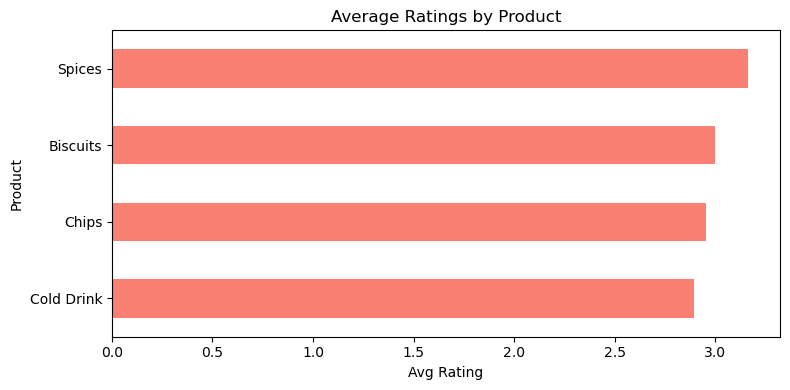

In [13]:
avg_ratings = df.groupby("Product")["Rating"].mean().sort_values()
plt.figure(figsize=(8, 4))
avg_ratings.plot(kind="barh", color="salmon")
plt.title("Average Ratings by Product")
plt.xlabel("Avg Rating")
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26500\878815713.py:8: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


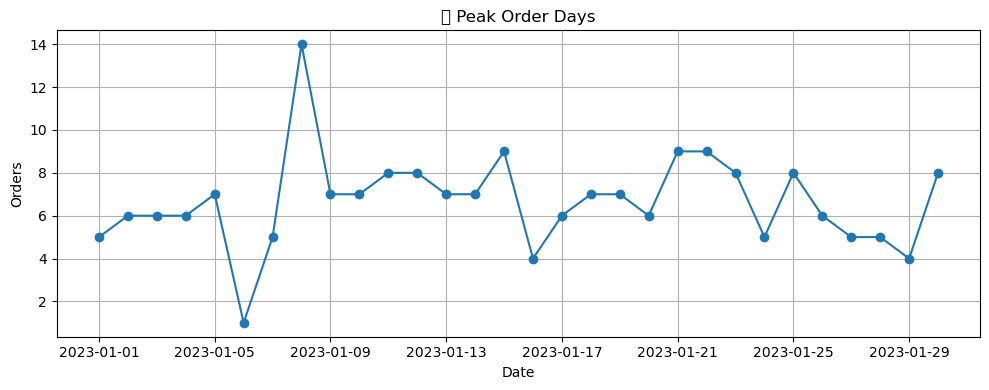

In [14]:
orders_per_day = df["Order_Time"].dt.date.value_counts().sort_index()
plt.figure(figsize=(10, 4))
orders_per_day.plot(marker='o', linestyle='-')
plt.title("📈 Peak Order Days")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
print("\nSummary Insights for E-Commerce Strategy:")
print(f"- Stock more of: {stock_data.idxmax()} (sold {stock_data.max()} units)")
print(f"- Most active customer: {user_orders.idxmax()} (ordered {user_orders.max()} times)")
print(f"- Best rated product: {avg_ratings.idxmax()} ({avg_ratings.max():.2f}/5)")


Summary Insights for E-Commerce Strategy:
- Stock more of: Biscuits (sold 147 units)
- Most active customer: U0001 (ordered 1 times)
- Best rated product: Spices (3.16/5)
